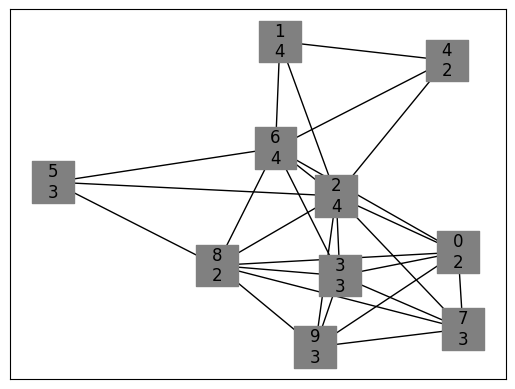

In [4]:
from math import gcd
import networkx as nx

from graphs import build_chordal_graph, scale_graph, plot_graph

NUM_VARIABLES = 10
NUM_TREE_NODES = 5
SUBTREE_GROWTH_PROB = 0.4
SEED = 113
WEIGHT_CHOICES = None
WEIGHT_CHOICES = (4,6,8)

cg = build_chordal_graph(NUM_VARIABLES, NUM_TREE_NODES, SUBTREE_GROWTH_PROB, SEED, WEIGHT_CHOICES)
W = nx.get_node_attributes(cg, 'weight')
W_gcd=gcd(*(W.values()))
cg = scale_graph(cg, W_gcd, 'down')
plot_graph(cg)


=== Solver Metrics ===
Status      : 2
Runtime     : 0.0012 s
Variables   : 38
Constraints : 49
Nonzeros    : 114
Nodes       : 1.0
Iterations  : 16
Solutions   : 2
Objective   : 19.0000
Best Bound  : 19.0000
MIP Gap     : 0.000000

=== Solution ===
Number of colors: 6
  Color 0: rep=0, heaviest=0 (w=2), members={0}
  Color 1: rep=2, heaviest=2 (w=4), members={2}
  Color 2: rep=3, heaviest=1 (w=4), members={1, 3}
  Color 3: rep=4, heaviest=9 (w=3), members={9, 4, 5}
  Color 4: rep=7, heaviest=6 (w=4), members={6, 7}
  Color 5: rep=8, heaviest=8 (w=2), members={8}


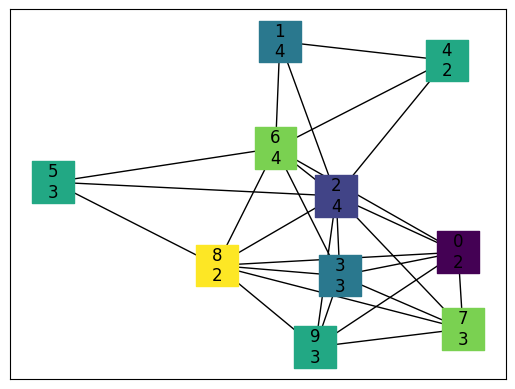

In [5]:
from gurobi import weighted_coloring as wc
G = cg.copy()
wc(G)
plot_graph(G)


=== Solver Metrics ===
Status      : 2
Runtime     : 0.1024 s
Variables   : 281
Constraints : 1502
Nonzeros    : 6448
Nodes       : 1.0
Iterations  : 822
Solutions   : 4
Objective   : 17.0000
Best Bound  : 17.0000
MIP Gap     : 0.000000

=== Solution ===
Memory used: 17
Vertex 0: start=9, block=[9, 10]
Vertex 1: start=6, block=[6, 7, 8, 9]
Vertex 2: start=0, block=[0, 1, 2, 3]
Vertex 3: start=4, block=[4, 5, 6]
Vertex 4: start=4, block=[4, 5]
Vertex 5: start=9, block=[9, 10, 11]
Vertex 6: start=12, block=[12, 13, 14, 15]
Vertex 7: start=11, block=[11, 12, 13]
Vertex 8: start=7, block=[7, 8]
Vertex 9: start=14, block=[14, 15, 16]


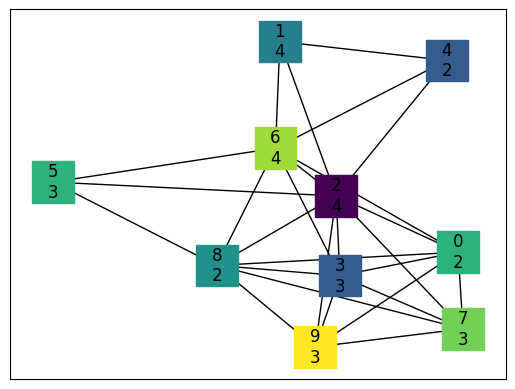

In [6]:
from math import gcd

import networkx as nx
from gurobi import consecutive_coloring as cc

G = cg.copy()
cc(G)
plot_graph(G)